# TP3 — Inverse problems with PINNs

**Scientific Machine Learning · ENSEEIHT / Toulouse INP · Spring 2026**

In this lab you will solve two **inverse problems** with PINNs:

1. **Scalar identification.**  Recover an unknown constant diffusivity
   $\lambda^\star$ from sparse, noisy observations of the solution.
2. **Field identification.**  Recover a spatially-varying conductivity
   $\kappa^\star(x)$,  where the unknown parameter is itself represented by a neural network.

Both experiments run in a few minutes on CPU.


---
## Part 0 — Setup

### The inverse problem

Consider the 1D steady-state diffusion equation on $\Omega = (0,1)$:
$$
-\lambda^\star\,u''(x) \;=\; f(x), \qquad u(0)=u(1)=0,
$$
with ground-truth conductivity $\lambda^\star = 0.7$ and manufactured solution
$u^\star(x) = \sin(\pi x)$.  The corresponding source term is therefore
$f(x) = \lambda^\star \pi^2 \sin(\pi x)$.

We assume $\lambda^\star$ is **unknown** and are given $N_d=20$ noisy
measurements
$$
y_k = u^\star(x_k^d) + \varepsilon_k,
\qquad \varepsilon_k \overset{\text{i.i.d.}}{\sim}\mathcal{N}(0,\sigma^2),
$$
at locations $\{x_k^d\}$ drawn uniformly in $(0,1)$.  Our goal is to recover
both the state $u$ *and* the scalar $\lambda^\star$ jointly.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.autograd import grad

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cpu")

PI = math.pi
LAMBDA_STAR = 0.7           # true (unknown to the PINN) conductivity
N_D = 20                    # number of noisy observations
N_R = 500                   # number of PDE collocation points per epoch

def u_star(x):
    return torch.sin(PI * x)

def f(x):
    # f(x) = lambda_star * pi^2 * sin(pi x)  so that -lambda_star u'' = f
    return LAMBDA_STAR * (PI ** 2) * torch.sin(PI * x)


### Neural network and hard-BC ansatz

We use a small MLP with $\tanh$ activations and the **hard-boundary** ansatz
$$
\widehat u_\theta(x) \;=\; x(1-x)\,\phi_\theta(x),
$$
so that $\widehat u_\theta(0) = \widehat u_\theta(1) = 0$ by construction.
This removes the BC loss term entirely and keeps the weight discussion
focused on the two terms that matter for the inverse setting: the
**PDE residual loss** $\widehat{\mathcal L}_r$ and the **data misfit**
$\widehat{\mathcal L}_d$.


In [15]:
class MLP(nn.Module):
    def __init__(self, in_dim=1, width=32, depth=3, out_dim=1):
        super().__init__()
        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, out_dim)]
        self.net = nn.Sequential(*layers)


    def forward(self, x):
        return self.net(x)

def u_hat(phi, x):
    '''Hard-BC ansatz: u_hat(x) = x(1-x) * phi(x).'''
    
    # TODO:: implement the hard-BC ansatz, given output of the MLP phi and input x
    u_hat = x * (1 - x) * phi(x)
    return u_hat


### Synthetic data generation

We generate $N_d$ noisy measurements.  The helper also returns the locations
and the clean values so we can visualise the setup.


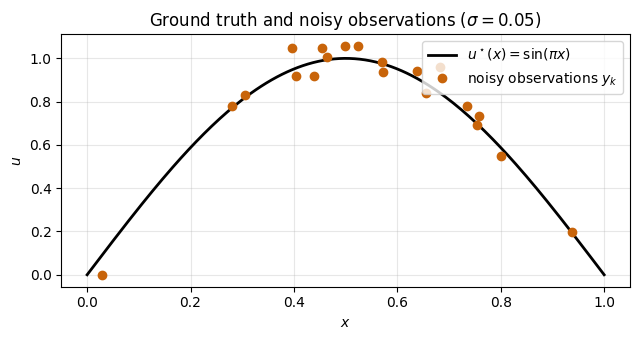

In [16]:
def generate_data(N_d=N_D, sigma=1e-2, seed=0):
    g = torch.Generator().manual_seed(seed)
    x_d = torch.rand(N_d, 1, generator=g)
    y_clean = u_star(x_d)
    y_d = y_clean + sigma * torch.randn(N_d, 1, generator=g)
    return x_d, y_d, y_clean

# Visualise: ground truth solution and a noisy sample
x_d, y_d, _ = generate_data(sigma=5e-2, seed=1)
x_grid = torch.linspace(0, 1, 200).reshape(-1, 1)

fig, ax = plt.subplots(1, 1, figsize=(6.5, 3.5))
ax.plot(x_grid, u_star(x_grid), 'k-', lw=2, label=r'$u^\star(x) = \sin(\pi x)$')
ax.plot(x_d, y_d, 'o', color='#C8640A', ms=6, label=r'noisy observations $y_k$')
ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$u$')
ax.set_title(r'Ground truth and noisy observations ($\sigma = 0.05$)')
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
## Part 1 — Scalar parameter identification

We parameterise the unknown conductivity as $\lambda_\psi = e^\psi$ with
$\psi \in \mathbb R$ a single trainable scalar.  The exponential
reparameterisation enforces $\lambda_\psi > 0$ without constrained
optimisation.

The inverse PINN loss reads
$$
\widehat{\mathcal L}_{\mathrm{inv}}(\theta,\psi)
  = \frac{\gamma_r}{N_r}\sum_{i=1}^{N_r}
    \bigl|-e^\psi\,\widehat u_\theta''(x_i^r) - f(x_i^r)\bigr|^2
  + \frac{\gamma_d}{N_d}\sum_{k=1}^{N_d}
    \bigl|\widehat u_\theta(x_k^d) - y_k^d\bigr|^2,
$$
with $\gamma_r, \gamma_d > 0$ fixed for now.  Both $\theta$ and $\psi$ are
optimised **simultaneously** by the same Adam optimiser.

---

**Question 1.** Why do we reparameterise as $\lambda_\psi = e^\psi$ rather
than treating $\lambda$ directly as a trainable scalar?  Give two reasons.

**Question 2.** Explain both parts of loss. What is seach term responsible for?

**Your answers:** *Enter your answers here.*


Answers for part 1
Question 1 :

1-To guarantee physical realism (positivity): The physical conductivity ($\lambda$) of a material must always be greater than zero. By using the exponential function ($e^\psi$), we mathematically guarantee that the resulting $\lambda$ will strictly be positive, regardless of the value of $\psi$. 
2-To simplify the training process: This trick allows us to enforce the positivity rule without having to use complex "constrained optimization" methods. The neural network can freely search for any real number for $\psi$ (from negative to positive infinity) without the risk of outputting an impossible, negative conductivity.

Question 2 : 
The data misfit loss ($\widehat{\mathcal L}_d$): This term is responsible for matching the real-world observations. It measures the difference (error) between what the neural network predicts and the actual noisy data points we have collected. It forces the solution to pass through the known measurements.  The PDE residual loss ($\widehat{\mathcal L}_r$): This term is responsible for enforcing the laws of physics. It measures how much the network's predicted curve disobeys the mathematical system (the Partial Differential Equation). It forces the solution to be physically realistic, even in the spaces between our actual data points.  

**TODO:** Implement the inverse PINN loss function below.
It must return the *total* loss (already weighted by $\gamma_r, \gamma_d$)
as well as the two *un-weighted* component losses
$\widehat{\mathcal L}_r$ and $\widehat{\mathcal L}_d$, so we can monitor
each term separately during training. To do so, you also need to implement pde residual term in pde_residual function. 


In [36]:
def pde_residual(phi, lam, x_r):
    '''Evaluate the PDE residual  r(x) = -lambda * u''(x) - f(x).
    Uses autograd through the hard-BC ansatz u_hat.'''
    x = x_r.clone().requires_grad_(True)
    
    # TODO:: compute the PDE residual at the collocation points x_r, 
    # using autograd to compute second derivatives of u_hat
    u = u_hat(phi, x)
    u_x  =  grad(u.sum(), x,  create_graph=True)[0]
    u_xx =  grad(u_x.sum(), x,  create_graph=True)[0]
    residual = -lam * u_xx - f(x)
    return residual


In [37]:
def inv_pinn_loss(phi, log_lam, x_r, x_d, y_d, gamma_r=1.0, gamma_d=1.0):
    '''Return (total, L_r, L_d) where L_r and L_d are the un-weighted
    MSE components and `total = gamma_r * L_r + gamma_d * L_d`.'''
    lam = torch.exp(log_lam)

    # TODO:: compute the PDE residual loss L_r and data loss L_d, 
    # then combine into total loss
    res  =  pde_residual(phi, lam, x_r)
    L_r  =  torch.mean(res ** 2)

    u_pred =  u_hat(phi, x_d)
    L_d    =  torch.mean((u_pred - y_d) ** 2)

    total = gamma_r * L_r + gamma_d * L_d
    return total, L_r, L_d


**Question 3.** Why is it useful to track $\widehat{\mathcal L}_r$ and
$\widehat{\mathcal L}_d$ **separately**, rather than only the total loss?

**Your answer:** *Enter your answer here.*

---

**TODO:** Complete the training loop below.  At each epoch you should
resample $N_r$ random collocation points in $(0,1)$ and take one Adam step.


In [38]:
def train_fixed(sigma=1e-2, gamma_r=1.0, gamma_d=1.0,
                n_epochs=3000, N_r=N_R, lr=1e-3, seed=0,
                data_seed=1, log_every=50, verbose=True):
    '''Train PINN + scalar lambda with fixed loss weights.
    Returns the trained models and a history dict.'''
    torch.manual_seed(seed)
    phi     = MLP(width=32, depth=3)
    log_lam = nn.Parameter(torch.tensor([0.0]))   # init lambda = 1

    x_d, y_d, _ = generate_data(sigma=sigma, seed=data_seed)
    optimizer = torch.optim.Adam([*phi.parameters(), log_lam], lr=lr)
    history = {'epoch': [], 'L_r': [], 'L_d': [], 'lambda': []}
    
    for epoch in range(n_epochs):
        
        # Sample N_r random PDE collocation points in the interior of the domain
        x_r = torch.rand(N_r, 1)
        
        optimizer.zero_grad()
        total, L_r, L_d = inv_pinn_loss(phi, log_lam, x_r, x_d, y_d,
                                        gamma_r=gamma_r, gamma_d=gamma_d)
        
        # TODO:: compute gradient of total loss and take an optimization step
        total.backward()
        optimizer.step()
        
        
        if epoch % log_every == 0:
            history['epoch'].append(epoch)
            history['L_r'].append(L_r.item())
            history['L_d'].append(L_d.item())
            history['lambda'].append(torch.exp(log_lam).item())
            if verbose and epoch % (log_every * 10) == 0:
                print(f"  epoch {epoch:5d}  L_r={L_r.item():.3e}  "
                      f"L_d={L_d.item():.3e}  lambda={torch.exp(log_lam).item():.4f}")

    return phi, log_lam, x_d, y_d, history


### Baseline run: $\gamma_r = \gamma_d = 1$

Let us first train with **uniform weights** and see what happens.


In [39]:
print(f"[Baseline]  gamma_r = gamma_d = 1,  sigma = 1e-2")
phi0, log_lam0, x_d0, y_d0, hist0 = train_fixed(
    sigma=1e-2, gamma_r=1.0, gamma_d=1.0, n_epochs=5000)
print(f"\nRecovered lambda = {torch.exp(log_lam0).item():.4f}   "
      f"(true: {LAMBDA_STAR})")


[Baseline]  gamma_r = gamma_d = 1,  sigma = 1e-2
  epoch     0  L_r=2.843e+01  L_d=7.798e-01  lambda=0.9990
  epoch   500  L_r=2.151e-03  L_d=7.020e-02  lambda=1.0215
  epoch  1000  L_r=1.565e-03  L_d=4.674e-02  lambda=0.9411
  epoch  1500  L_r=1.270e-03  L_d=2.287e-02  lambda=0.8520
  epoch  2000  L_r=5.068e-04  L_d=7.218e-03  lambda=0.7760
  epoch  2500  L_r=1.051e-04  L_d=1.282e-03  lambda=0.7271
  epoch  3000  L_r=5.270e-05  L_d=1.984e-04  lambda=0.7052
  epoch  3500  L_r=3.703e-05  L_d=1.075e-04  lambda=0.6986
  epoch  4000  L_r=2.751e-05  L_d=1.043e-04  lambda=0.6972
  epoch  4500  L_r=2.116e-05  L_d=1.042e-04  lambda=0.6970

Recovered lambda = 0.6970   (true: 0.7)


### Diagnostic plot

The following three-panel figure summarises any training run: loss
components, $\lambda$ trajectory, and the final fit.  We will reuse it
throughout the TP.


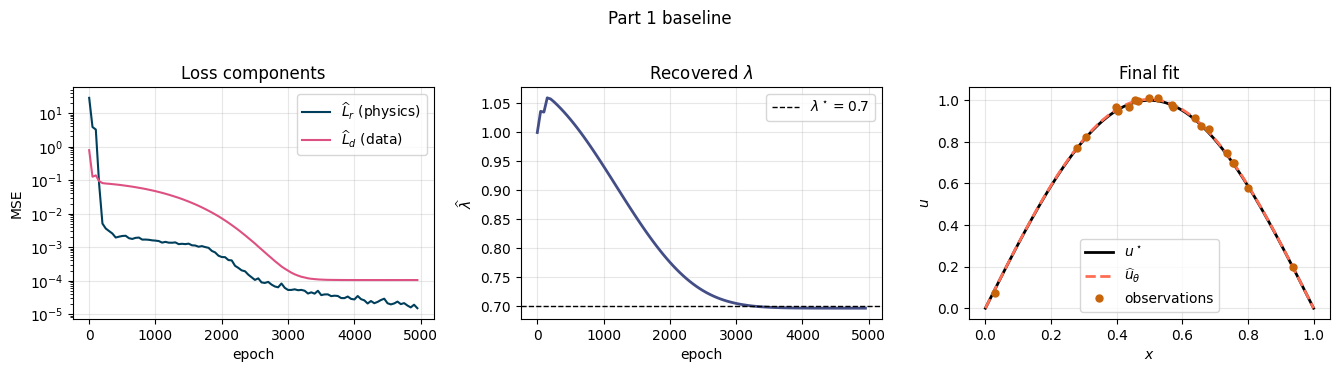

In [40]:
def plot_training_diagnostics(phi, log_lam, x_d, y_d, hist,
                               title_suffix='', ax_list=None):
    '''Three panels: (a) L_r and L_d on log scale, (b) lambda vs epoch,
    (c) final u_hat vs u_star and observations.'''
    if ax_list is None:
        fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
    else:
        axes = ax_list
    ax1, ax2, ax3 = axes

    ax1.semilogy(hist['epoch'], hist['L_r'], label=r'$\widehat{L}_r$ (physics)', color='#003F5C')
    ax1.semilogy(hist['epoch'], hist['L_d'], label=r'$\widehat{L}_d$ (data)', color='#DD5182')
    ax1.set_xlabel('epoch'); ax1.set_ylabel('MSE'); ax1.grid(alpha=0.3)
    ax1.set_title('Loss components'); ax1.legend(loc='best')

    ax2.plot(hist['epoch'], hist['lambda'], color='#444E86', lw=2)
    ax2.axhline(LAMBDA_STAR, color='k', ls='--', lw=1, label=fr'$\lambda^\star = {LAMBDA_STAR}$')
    ax2.set_xlabel('epoch'); ax2.set_ylabel(r'$\widehat\lambda$')
    ax2.set_title(r'Recovered $\lambda$'); ax2.legend(loc='best'); ax2.grid(alpha=0.3)

    with torch.no_grad():
        xg = torch.linspace(0, 1, 200).reshape(-1, 1)
        ug = u_hat(phi, xg)
    ax3.plot(xg, u_star(xg), 'k-', lw=2, label=r'$u^\star$')
    ax3.plot(xg, ug, color='#FF6E54', lw=2, ls='--', label=r'$\widehat{u}_\theta$')
    ax3.plot(x_d, y_d, 'o', color='#C8640A', ms=5, label='observations')
    ax3.set_xlabel(r'$x$'); ax3.set_ylabel(r'$u$')
    ax3.set_title('Final fit'); ax3.legend(loc='best'); ax3.grid(alpha=0.3)

    if ax_list is None:
        plt.suptitle(f'Part 1 baseline{title_suffix}', y=1.02, fontsize=12)
        plt.tight_layout(); plt.show()

plot_training_diagnostics(phi0, log_lam0, x_d0, y_d0, hist0)


**Question 4.** From the diagnostic plot of the baseline run, does
$\widehat u_\theta$ match $u^\star$?  Is $\widehat\lambda$ close to
$\lambda^\star = 0.7$?  If one is accurate but the other is not, explain
why that makes sense from the *relative scale* of
$\widehat{\mathcal L}_r$ vs $\widehat{\mathcal L}_d$ you see in panel (a).

**Your answer:** *Enter your answer here.*


---
## Part 2 — Field identification in 2D

We now consider a **much richer inverse problem**: the unknown is no longer a
scalar, but a *function* $\kappa^\star:\Omega\to\mathbb{R}_{>0}$ defined on
a two-dimensional domain.  This is the prototype situation behind problems
such as **Electrical Impedance Tomography (EIT)**, where one tries to image
hidden inclusions (tumors, cracks, voids, …) from measurements of a
physical field.

### Problem statement

On the unit square $\Omega = (0,1)^2$, consider the non-constant-coefficient
diffusion equation in **divergence form**
$$
-\nabla\!\cdot\!\bigl[\kappa^\star(x,y)\,\nabla u(x,y)\bigr] \;=\; f(x,y),
\qquad u\big|_{\partial\Omega}=0.
$$
The ground-truth conductivity hides **two Gaussian bumps** ("dumbbell") on a
uniform background:
$$
\kappa^\star(x,y) \;=\; 1 \;+\; A\sum_{i=1}^{2}
   \exp\!\bigl(-\beta\,\|(x,y)-c_i\|^2\bigr),
\qquad A=2,\ \beta=60,
$$
with centres $c_1=(0.3,0.3)$ and $c_2=(0.7,0.7)$.  We manufacture
$u^\star(x,y)=\sin(\pi x)\sin(\pi y)$ and derive $f$ analytically from
$-\nabla\!\cdot\!(\kappa^\star\nabla u^\star)$.

We observe $N_d = 80$ noisy samples of $u^\star$ at random interior
locations with noise level $\sigma = 10^{-2}$, and we are **not** told
where the defects are, how many there are, or what shape they take.

### Why a network for $\kappa$?

The parameter $\kappa^\star$ is **infinite-dimensional** — we cannot
optimise it as a single scalar (as in Part 1) or as a modest finite
vector, because we do not know its shape, number of inclusions, or
spatial scale in advance.  

A natural choice is to represent it by its own
MLP:
$$
\kappa_\psi(x,y) \;=\; \exp\!\bigl(\,\mathrm{MLP}_\psi(x,y)\bigr).
$$
The exponential parameterisation guarantees **positivity**
($\kappa_\psi > 0$), a physical constraint for a diffusion coefficient.
If we initialise the last layer to zero, we start from the natural prior
$\kappa_\psi \equiv 1$ (the background).

The joint model therefore has **two networks**:

* $\varphi_\theta:\mathbb R^2\to\mathbb R$ for the state $u$ (with hard
  BCs as before),
* $\kappa_\psi:\mathbb R^2\to\mathbb R_{>0}$ for the conductivity field,

and we optimise $(\theta,\psi)$ **jointly** to minimise
$$
\mathcal L(\theta,\psi)
\;=\; \gamma_r\,\widehat{\mathcal L}_r(\theta,\psi)
\;+\; \gamma_d\,\widehat{\mathcal L}_d(\theta),
$$
where $\widehat{\mathcal L}_r$ is the squared residual of the divergence-form
PDE and $\widehat{\mathcal L}_d$ the mean-squared data misfit.

### The truth we are trying to recover

Let us first visualise the hidden defect, the ground-truth state $u^\star$
and the observation locations.  Note how the two bumps in $\kappa^\star$
leave **no visible trace** on $u^\star$: the state is essentially the
unperturbed background mode $\sin(\pi x)\sin(\pi y)$.  The information
about the inclusions lives in the residual
$-\nabla\!\cdot\!(\kappa\nabla u)-f$ once we enforce it.

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


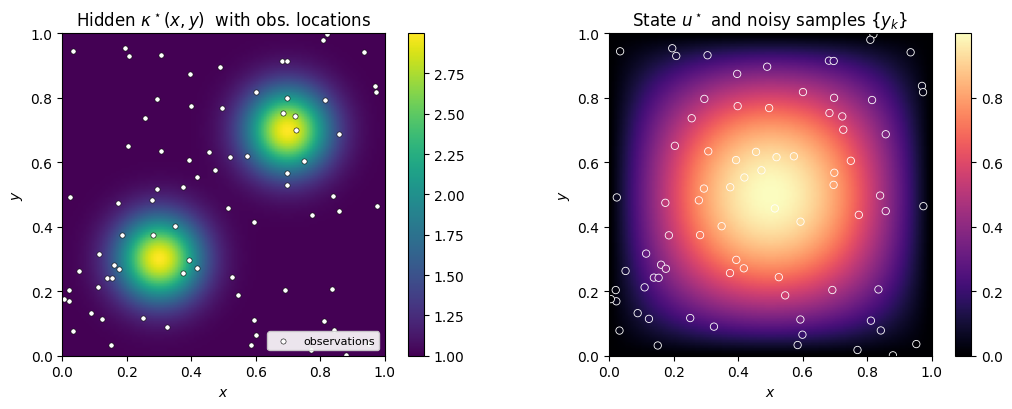

In [41]:
A, BETA = 2.0, 60.0
C1 = torch.tensor([[0.3, 0.3]])
C2 = torch.tensor([[0.7, 0.7]])

def kappa_star(xy):
    r1 = ((xy - C1) ** 2).sum(dim=1, keepdim=True)
    r2 = ((xy - C2) ** 2).sum(dim=1, keepdim=True)
    return 1.0 + A * torch.exp(-BETA * r1) + A * torch.exp(-BETA * r2)

def u_star_2d(xy):
    return torch.sin(PI * xy[:, 0:1]) * torch.sin(PI * xy[:, 1:2])

def f_field(xy):
    """Analytical RHS so that  -div(kappa_star * grad u_star) = f."""
    x, y = xy[:, 0:1], xy[:, 1:2]
    sx, sy = torch.sin(PI * x), torch.sin(PI * y)
    cx, cy = torch.cos(PI * x), torch.cos(PI * y)
    r1 = ((xy - C1) ** 2).sum(dim=1, keepdim=True)
    r2 = ((xy - C2) ** 2).sum(dim=1, keepdim=True)
    g1, g2 = torch.exp(-BETA * r1), torch.exp(-BETA * r2)
    k  = 1.0 + A * g1 + A * g2
    # grad kappa
    kx = -2.0 * BETA * A * ((x - C1[0, 0]) * g1 + (x - C2[0, 0]) * g2)
    ky = -2.0 * BETA * A * ((y - C1[0, 1]) * g1 + (y - C2[0, 1]) * g2)
    # grad u and laplacian of u
    ux, uy = PI * cx * sy, PI * sx * cy
    lap_u  = -2.0 * PI ** 2 * sx * sy
    return -(kx * ux + ky * uy + k * lap_u)

N_D_FIELD    = 80
SIGMA_FIELD  = 1e-2

def generate_data_field(N_d=N_D_FIELD, sigma=SIGMA_FIELD, seed=0):
    g = torch.Generator().manual_seed(seed)
    xy_d = torch.rand(N_d, 2, generator=g)
    y_d  = u_star_2d(xy_d) + sigma * torch.randn(N_d, 1, generator=g)
    return xy_d, y_d

# --- visualise truth + data ------------------------------------------------
def _grid(ng):
    xs = torch.linspace(0, 1, ng)
    YY, XX = torch.meshgrid(xs, xs)                       # rows <-> y, cols <-> x
    return torch.stack([XX.reshape(-1), YY.reshape(-1)], dim=1), ng

xy_d_f, y_d_f = generate_data_field()
xy_g, NG = _grid(120)
K  = kappa_star(xy_g).reshape(NG, NG).numpy()
U  = u_star_2d(xy_g).reshape(NG, NG).numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
im0 = axes[0].imshow(K, origin='lower', extent=[0, 1, 0, 1], cmap='viridis')
axes[0].scatter(xy_d_f[:, 0], xy_d_f[:, 1], c='white', s=14,
                edgecolor='k', lw=0.4, label='observations')
axes[0].set_title(r'Hidden $\kappa^\star(x,y)$  with obs. locations')
axes[0].set_xlabel(r'$x$'); axes[0].set_ylabel(r'$y$')
axes[0].legend(loc='lower right', framealpha=0.9, fontsize=8)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(U, origin='lower', extent=[0, 1, 0, 1], cmap='magma')
axes[1].scatter(xy_d_f[:, 0], xy_d_f[:, 1], c=y_d_f.squeeze().numpy(),
                cmap='magma', s=28, edgecolor='w', lw=0.6,
                vmin=U.min(), vmax=U.max())
axes[1].set_title(r'State $u^\star$ and noisy samples $\{y_k\}$')
axes[1].set_xlabel(r'$x$'); axes[1].set_ylabel(r'$y$')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

**Observation.**  The state $u^\star$ in the right panel looks almost
perfectly like the background mode $\sin(\pi x)\sin(\pi y)$: one cannot
see the defects by eye.  That is precisely what makes field-inverse
problems hard — the two bumps in $\kappa$ couple to $u$ only
through the divergence of the flux $\kappa\nabla u$, and that signature
is small and spatially concentrated. 

### A note on loss weights

For the scalar problem of Part 1, $\gamma_r = \gamma_d = 1$ worked out of
the box.  For this field problem the unknown has *many more* degrees of
freedom than a single scalar and the data term needs more weight to drive
identifiability; we fix $\gamma_d = 100$.  


**TODO:**  Complete the loss evaluation for the 2D field problem below. 
 Note the **divergence form** of the residual is computed as
$$
-\nabla\!\cdot\!\bigl[\kappa_\psi(x,y)\,\nabla u\bigr]
= -\partial_x\!\bigl(\kappa_\psi\,\partial_x u\bigr)
  -\partial_y\!\bigl(\kappa_\psi\,\partial_y u\bigr).
$$
Three `grad` calls are sufficient: one for $\nabla u$, and one each for
the two components of $\nabla\!\cdot\!(\kappa_\psi\nabla u)$.

In [42]:
def u_hat_2d(phi, xy):
    """Hard-BC ansatz on (0,1)^2:  u(x,y) = x(1-x) y(1-y) * phi(x,y)."""
    x, y = xy[:, 0:1], xy[:, 1:2]
    return x * (1.0 - x) * y * (1.0 - y) * phi(xy)

def kappa_net(kp, xy):
    """kappa_psi(x,y) = exp(MLP_psi(x,y)) — positivity by construction."""
    return torch.exp(kp(xy))

def pde_residual_field(phi, kp, xy_r):
    """Residual of  -div( kappa_psi * grad u_hat ) - f(x,y)."""
    xy   = xy_r.clone().requires_grad_(True)
    u    = u_hat_2d(phi, xy)
    ug   = grad(u.sum(), xy, create_graph=True)[0]          # [N, 2]
    flux = kappa_net(kp, xy) * ug                           # [N, 2]
    div_x = grad(flux[:, 0].sum(), xy, create_graph=True)[0][:, 0:1]
    div_y = grad(flux[:, 1].sum(), xy, create_graph=True)[0][:, 1:2]
    return -(div_x + div_y) - f_field(xy)

def inv_pinn_loss_field(phi, kp, xy_r, xy_d, y_d, gamma_r=1.0, gamma_d=100.0):
    # TODO:: Compute the PDE residual loss L_r and data loss L_d, 
    # then combine into total loss
    
    res  =  pde_residual_field(phi, kp, xy_r)
    L_r  =  torch.mean(res ** 2)
    u_pred =  u_hat_2d(phi, xy_d)
    L_d    =  torch.mean((u_pred - y_d) ** 2)
    total =  gamma_r * L_r + gamma_d * L_d
    return total, L_r, L_d

**TODO**  Write a training loop that jointly optimises
$(\varphi_\theta,\kappa_\psi)$.  Keep track of the two loss components
$(\widehat{\mathcal L}_r,\widehat{\mathcal L}_d)$ as well as the
$L^\infty$ and $L^2$ errors of $\widehat\kappa$ against $\kappa^\star$ on
a fixed fine grid.  A cosine LR schedule from $2\!\times\!10^{-3}$ down
to $2\!\times\!10^{-4}$ helps sharpen the bumps towards the end of
training.

In [44]:
def train_field(sigma=SIGMA_FIELD, gamma_d=100.0, n_epochs=5000,
                lr=2e-3, N_r=1500, data_seed=0, model_seed=0, log_every=100):
    torch.manual_seed(model_seed)
    # TODO:: Create two MLPs: one for the state u_hat and one for the conductivity kappa_psi.
    # For both nets, use width=32 and depth=3. 
    # Note, we initialize kappa_net to output 0 (i.e. kappa_psi ≡ 1)
    # State network
    # phi = ... 
    # Conductivity network
    # kp  = ... 
    phi = MLP(in_dim=2, width=32, depth=3)
    kp  = MLP(in_dim=2, width=32, depth=3)

    
    
    # start from the uniform prior  kappa_psi(x,y) ≡ 1
    with torch.no_grad():
        kp.net[-1].weight.zero_(); kp.net[-1].bias.zero_()


    xy_d, y_d = generate_data_field(sigma=sigma, seed=data_seed)

    # We optimize over parameters of both nets jointly
    opt  = torch.optim.Adam([*phi.parameters(), *kp.parameters()], lr=lr)

    # We use a cosine annealing schedule for the learning rate, 
    # which empirically helps convergence in this problem
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=2e-4)

    xy_g, _ = _grid(60)        # coarse grid for cheap in-loop error tracking
    hist = {'epoch': [], 'Lr': [], 'Ld': [],
            'kappa_err_inf': [], 'kappa_err_L2': []}

    for epoch in range(n_epochs):
        xy_r = torch.rand(N_r, 2)
        opt.zero_grad()
        total, L_r, L_d = inv_pinn_loss_field(phi, kp, xy_r, xy_d, y_d,
                                              gamma_r=1.0, gamma_d=gamma_d)
        
        # TODO:: 1. compute gradient of total loss 
        # 2. take an optimization step
        # 3. take an scheduler step
        total.backward()
        opt.step()
        sched.step()
        

        if epoch % log_every == 0 or epoch == n_epochs - 1:
            with torch.no_grad():
                diff = kappa_net(kp, xy_g) - kappa_star(xy_g)
                hist['kappa_err_inf'].append(diff.abs().max().item())
                hist['kappa_err_L2'].append((diff ** 2).mean().sqrt().item())
            hist['epoch'].append(epoch)
            hist['Lr'].append(L_r.item()); hist['Ld'].append(L_d.item())

    return phi, kp, xy_d, y_d, hist


print('[Field] training two 2D networks jointly — ~2 minutes on CPU …')
phi_f, kp_f, xy_d_f, y_d_f, hist_f = train_field(n_epochs=5000)
print(f"final  L_r  = {hist_f['Lr'][-1]:.3e}")
print(f"final  L_d  = {hist_f['Ld'][-1]:.3e}")
print(f"||kappa_hat - kappa*||_inf = {hist_f['kappa_err_inf'][-1]:.3f}")
print(f"||kappa_hat - kappa*||_L2  = {hist_f['kappa_err_L2'][-1]:.3f}")

[Field] training two 2D networks jointly — ~2 minutes on CPU …
final  L_r  = 3.541e-02
final  L_d  = 2.346e-04
||kappa_hat - kappa*||_inf = 0.661
||kappa_hat - kappa*||_L2  = 0.171


### Visual diagnostics

The figure below summarises the run with six panels: (a) true and (b)
recovered conductivity as heatmaps (same colour scale), (c) their
pointwise difference, (d) recovered state $\widehat u_\theta$, (e) loss
components versus epoch, and (f) convergence of
$\|\widehat\kappa-\kappa^\star\|$ in $L^\infty$ and $L^2$.

In [ ]:
def plot_field_diagnostics(phi, kp, xy_d, y_d, hist):
    xy_g, ng = _grid(120)
    with torch.no_grad():
        k_true  = kappa_star(xy_g).reshape(ng, ng).numpy()
        k_hat   = kappa_net(kp, xy_g).reshape(ng, ng).numpy()
        u_hat_g = u_hat_2d(phi, xy_g).reshape(ng, ng).numpy()
    err = k_hat - k_true
    vmax_k = max(k_true.max(), k_hat.max())
    vmax_e = float(abs(err).max())

    fig, axes = plt.subplots(2, 3, figsize=(13.5, 8))

    # (a) kappa_star
    ax = axes[0, 0]
    im = ax.imshow(k_true, origin='lower', extent=[0, 1, 0, 1],
                   cmap='viridis', vmin=1.0, vmax=vmax_k)
    ax.set_title(r'(a)  true $\kappa^\star(x,y)$')
    ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$y$')
    plt.colorbar(im, ax=ax, fraction=0.046)

    # (b) kappa_hat with observation overlay
    ax = axes[0, 1]
    im = ax.imshow(k_hat, origin='lower', extent=[0, 1, 0, 1],
                   cmap='viridis', vmin=1.0, vmax=vmax_k)
    ax.scatter(xy_d[:, 0], xy_d[:, 1], c='white', s=12,
               edgecolor='k', lw=0.4)
    ax.set_title(r'(b)  recovered $\widehat\kappa_\psi$   (+ observations)')
    ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$y$')
    plt.colorbar(im, ax=ax, fraction=0.046)

    # (c) signed error
    ax = axes[0, 2]
    im = ax.imshow(err, origin='lower', extent=[0, 1, 0, 1],
                   cmap='RdBu_r', vmin=-vmax_e, vmax=vmax_e)
    ax.set_title(r'(c)  $\widehat\kappa - \kappa^\star$')
    ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$y$')
    plt.colorbar(im, ax=ax, fraction=0.046)

    # (d) recovered state
    ax = axes[1, 0]
    im = ax.imshow(u_hat_g, origin='lower', extent=[0, 1, 0, 1], cmap='magma')
    ax.set_title(r'(d)  recovered $\widehat u_\theta$')
    ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$y$')
    plt.colorbar(im, ax=ax, fraction=0.046)

    # (e) loss components
    ax = axes[1, 1]
    ax.semilogy(hist['epoch'], hist['Lr'], label=r'$\widehat{L}_r$',
                color='#003F5C', lw=1.8)
    ax.semilogy(hist['epoch'], hist['Ld'], label=r'$\widehat{L}_d$',
                color='#FF6E54', lw=1.8)
    ax.set_title('(e)  loss components'); ax.set_xlabel('epoch')
    ax.grid(alpha=0.3, which='both'); ax.legend(loc='best')

    # (f) kappa error
    ax = axes[1, 2]
    ax.semilogy(hist['epoch'], hist['kappa_err_inf'],
                label=r'$\|\widehat\kappa-\kappa^\star\|_\infty$',
                color='#003F5C', lw=1.8)
    ax.semilogy(hist['epoch'], hist['kappa_err_L2'],
                label=r'$\|\widehat\kappa-\kappa^\star\|_{L^2}$',
                color='#FF6E54', lw=1.8)
    ax.set_title(r'(f)  conductivity error'); ax.set_xlabel('epoch')
    ax.grid(alpha=0.3, which='both'); ax.legend(loc='best')

    plt.tight_layout(); plt.show()

plot_field_diagnostics(phi_f, kp_f, xy_d_f, y_d_f, hist_f)

**Question:** Re-run `train_field` with `data_seed=1, 2, 3` (keeping
`model_seed=0` fixed).  Is the *position* of each bump always recovered
correctly?  Is the *amplitude* as stable as the position?  Discuss why
field-inverse problems are typically well-posed for the **geometry** of
an inclusion but much less so for its **contrast**.

**Your answer:** *Enter your answer here.*

---

**Question:**  Suppose one of the two bumps were moved close to
a corner — e.g. $c_2 = (0.9, 0.9)$ — and that, by unlucky sampling, no
observations fell in the upper-right quadrant.  What would you expect
$\widehat\kappa_\psi$ to look like there?  What does this tell you about
the **identifiability** of field-inverse problems from sparse data?  Try
it by passing a different `data_seed` and choosing $c_2$ accordingly.

**Your answer:** *Enter your answer here.*

---
## Bonus: Loss-weight tuning: manual sweep and adaptive balancing

We fixed $\gamma_d = 100$ by hand in Part 2.  We now confront this choice
head-on.  First, we run a **manual sweep** over
$\gamma_d \in \{1, 10, 100, 1000\}$ to visualise how the reconstruction
degrades when the weights are mis-set.  Then we implement the
gradient-based **learning-rate-annealing** (LRA) scheme of
Wang, Teng & Perdikaris (2021, *SIAM J. Sci. Comput.* 43, A3055) to let
the PINN adapt $\gamma_d$ on its own.

### Experiment A — manual sweep

We reuse the 2D dumbbell problem but with a lighter training budget
($N_r=1000$, $2500$ epochs) so that four runs complete faster.  For each $\gamma_d$ we record the final
$\|\widehat\kappa-\kappa^\star\|_{L^2}$ and render the recovered field as
a heatmap on a common colour scale.

[sweep] running 4 fixed-weight fits — ~3 minutes total
   gamma_d =     1.0   final |kappa-kappa*|_L2 = 8.393
   gamma_d =    10.0   final |kappa-kappa*|_L2 = 1.549
   gamma_d =   100.0   final |kappa-kappa*|_L2 = 0.264
   gamma_d =  1000.0   final |kappa-kappa*|_L2 = 0.216


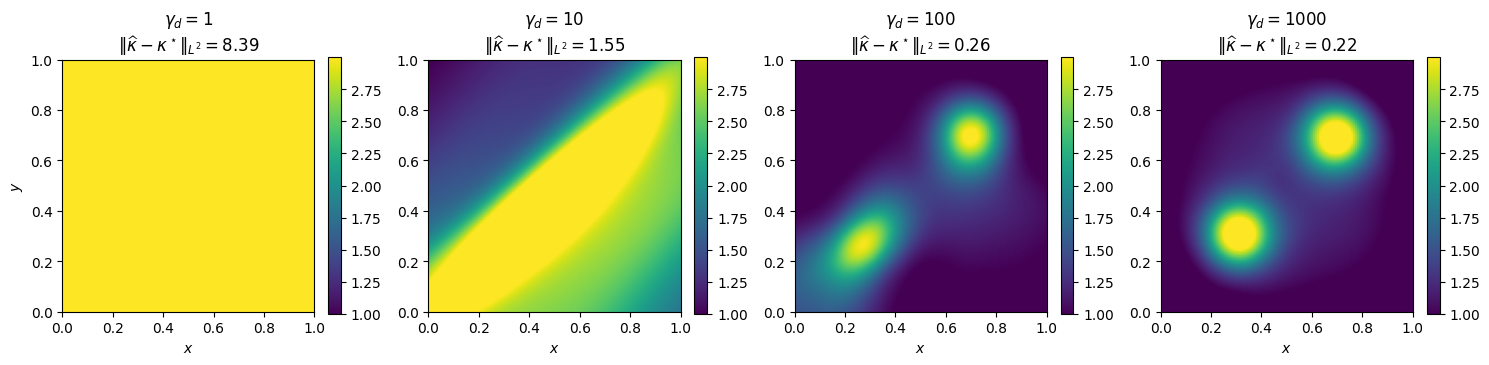

In [47]:
GAMMAS = [1.0, 10.0, 100.0, 1000.0]

sweep_results = {}
print(f"[sweep] running 4 fixed-weight fits — ~3 minutes total")
for g in GAMMAS:
    phi_s, kp_s, _, _, hist_s = train_field(
        gamma_d=g, n_epochs=2500, N_r=1000, log_every=100)
    sweep_results[g] = (phi_s, kp_s, hist_s)
    print(f"   gamma_d = {g:7.1f}   final |kappa-kappa*|_L2 = "
          f"{hist_s['kappa_err_L2'][-1]:.3f}")

# render the four recovered fields on a common scale
xy_g, ng = _grid(120)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
vmax = float(kappa_star(xy_g).max().item())
for i, g in enumerate(GAMMAS):
    phi_s, kp_s, hist_s = sweep_results[g]
    with torch.no_grad():
        K = kappa_net(kp_s, xy_g).reshape(ng, ng).numpy()
    im = axes[i].imshow(K, origin='lower', extent=[0, 1, 0, 1],
                         cmap='viridis', vmin=1.0, vmax=vmax)
    axes[i].set_title(
        rf'$\gamma_d = {int(g)}$' + '\n'
        + rf'$\|\widehat\kappa - \kappa^\star\|_{{L^2}}='
        + f'{hist_s["kappa_err_L2"][-1]:.2f}$')
    axes[i].set_xlabel(r'$x$')
    axes[i].set_ylabel(r'$y$' if i == 0 else '')
    plt.colorbar(im, ax=axes[i], fraction=0.046)
plt.tight_layout(); plt.show()

**Question:**  The four panels above trace the failure modes of fixed
weights.  Explain *mechanistically*, in terms of the gradient of the
total loss w.r.t. the state-network parameters $\theta$, why

(i) $\gamma_d = 1$ collapses $\widehat\kappa$ to something unrelated to
the truth (the PINN ignores the data entirely), and

(ii) making $\gamma_d$ large enough is *necessary*. However, is making
 $\gamma_d$ "larger" always better?  What can happen if $\gamma_d$ is too large?

**Your answer:** *Enter your answer here.*

---

### Experiment B — adaptive weighting (LRA scheme)

The manual sweep works but is wasteful: each trial costs a full run, and
the optimal $\gamma_d$ depends on the problem scale, the noise level, and
the network size.  Wang, Teng & Perdikaris (2021) observed that a
well-balanced PINN has

$$
\max_{\theta}\bigl|\nabla_\theta \widehat{\mathcal L}_r\bigr|
\;\approx\;
\gamma_d\,\overline{\bigl|\nabla_\theta \widehat{\mathcal L}_d\bigr|},
$$

where the mean is taken coordinate-wise over the state-network
parameters.  This suggests a **self-consistent update**

$$
\widehat\gamma_d(t) \;=\;
\frac{\max_{\theta}|\nabla_\theta \widehat{\mathcal L}_r|}
     {\overline{|\nabla_\theta \widehat{\mathcal L}_d|}},
\qquad
\log\gamma_d \;\leftarrow\;
(1-\alpha)\log\gamma_d + \alpha\log\widehat\gamma_d,
$$

applied every few steps ($\alpha \in (0,1)$ is a small EMA rate).  We
average in **log-space** (rather than linearly, as in the original
paper) because $\widehat\gamma_d$ varies across several orders of
magnitude, and we cap $\gamma_d$ at $10^4$ to prevent runaway once
$\widehat{\mathcal L}_d$ has been driven to noise level.

**TODO:** Understand the implementation of the helper functions `_grad_max_phi` and
`_grad_mean_phi` and the training function `train_field_adaptive`
following the scheme outlined above. 

In [48]:
def _grad_max_phi(loss, phi):
    """max_theta |d loss / d theta|  over state-network parameters."""
    gs = torch.autograd.grad(loss, phi.parameters(), retain_graph=True)
    return max(g.abs().max().item() for g in gs)

def _grad_mean_phi(loss, phi):
    """mean coordinate-wise |d loss / d theta|."""
    gs = torch.autograd.grad(loss, phi.parameters(), retain_graph=True)
    return sum(g.abs().sum().item() for g in gs) / sum(g.numel() for g in gs)

def train_field_adaptive(n_epochs=5000, N_r=1500, lr=2e-3,
                          alpha=0.05, gamma_max=1e4, update_every=10,
                          sigma=SIGMA_FIELD, data_seed=0, model_seed=0,
                          log_every=100):
    """Same as train_field but with the LRA adaptive scheme for gamma_d,
    started from gamma_d = 1 (physics-only initialisation)."""
    torch.manual_seed(model_seed)
    phi = MLP(in_dim=2, width=32, depth=3)
    kp  = MLP(in_dim=2, width=32, depth=3)
    with torch.no_grad():
        kp.net[-1].weight.zero_(); kp.net[-1].bias.zero_()

    xy_d, y_d = generate_data_field(sigma=sigma, seed=data_seed)
    opt   = torch.optim.Adam([*phi.parameters(), *kp.parameters()], lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=2e-4)

    xy_g, _ = _grid(60)
    gamma_d = 1.0
    hist = {'epoch': [], 'Lr': [], 'Ld': [], 'gamma_d': [],
            'kappa_err_inf': [], 'kappa_err_L2': []}

    for epoch in range(n_epochs):
        xy_r = torch.rand(N_r, 2)
        opt.zero_grad()
        res  = pde_residual_field(phi, kp, xy_r)
        L_r  = (res ** 2).mean()
        L_d  = ((u_hat_2d(phi, xy_d) - y_d) ** 2).mean()

        # self-consistent update:  gamma_d balances grad magnitudes on phi
        if epoch % update_every == 0:
            mx_r   = _grad_max_phi(L_r, phi)
            mn_d   = _grad_mean_phi(L_d, phi)
            gd_hat = min(mx_r / max(mn_d, 1e-12), gamma_max)
            gamma_d = math.exp((1 - alpha) * math.log(gamma_d)
                               + alpha * math.log(gd_hat))

        (L_r + gamma_d * L_d).backward()
        opt.step(); sched.step()

        if epoch % log_every == 0 or epoch == n_epochs - 1:
            with torch.no_grad():
                diff = kappa_net(kp, xy_g) - kappa_star(xy_g)
                hist['kappa_err_inf'].append(diff.abs().max().item())
                hist['kappa_err_L2'].append((diff ** 2).mean().sqrt().item())
            hist['epoch'].append(epoch)
            hist['Lr'].append(L_r.item()); hist['Ld'].append(L_d.item())
            hist['gamma_d'].append(gamma_d)

    return phi, kp, xy_d, y_d, hist


print('[adaptive] training with self-tuning gamma_d — ~2.5 minutes on CPU …')
phi_a, kp_a, xy_d_a, y_d_a, hist_a = train_field_adaptive(n_epochs=5000)
print(f"final gamma_d                        = {hist_a['gamma_d'][-1]:.1f}")
print(f"final |kappa_hat - kappa*|_L2         = {hist_a['kappa_err_L2'][-1]:.3f}")
print(f"  (best fixed-sweep value at shorter budget = "
      f"{min(sweep_results[g][2]['kappa_err_L2'][-1] for g in GAMMAS):.3f})")

[adaptive] training with self-tuning gamma_d — ~2.5 minutes on CPU …
final gamma_d                        = 10000.0
final |kappa_hat - kappa*|_L2         = 0.100
  (best fixed-sweep value at shorter budget = 0.216)


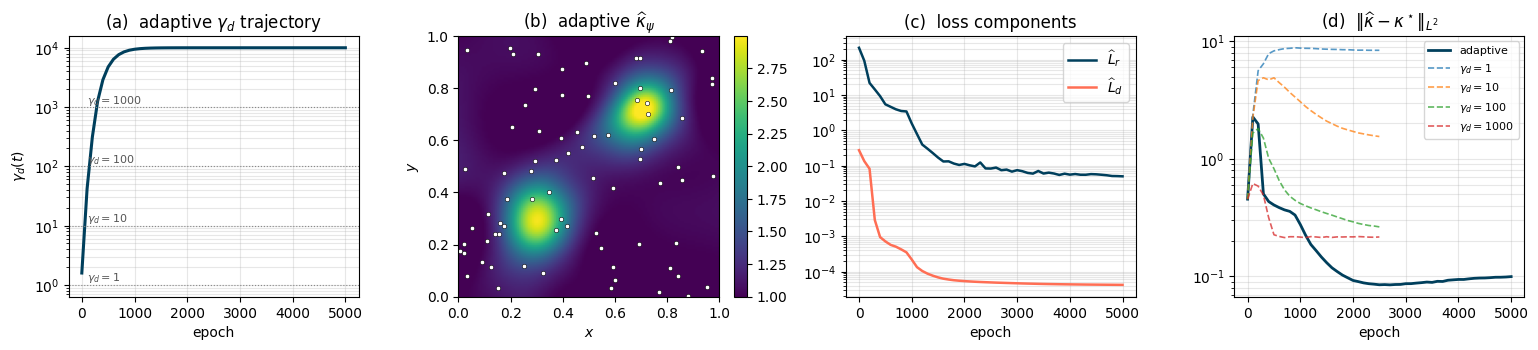

In [49]:
def plot_adaptive_diagnostics(phi, kp, xy_d, y_d, hist, sweep_results):
    """Four-panel summary of an adaptive-gamma_d run:
    (a) gamma_d(t) with fixed-sweep values overlaid,
    (b) recovered kappa,
    (c) loss components, (d) kappa-error convergence."""
    xy_g, ng = _grid(120)
    with torch.no_grad():
        K = kappa_net(kp, xy_g).reshape(ng, ng).numpy()

    fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.6))

    # (a) gamma_d trajectory
    ax = axes[0]
    ax.semilogy(hist['epoch'], hist['gamma_d'], color='#003F5C', lw=2.2)
    for g in GAMMAS:
        ax.axhline(g, color='#888', ls=':', lw=0.8)
        ax.text(hist['epoch'][-1] * 0.02, g * 1.15, rf'$\gamma_d={int(g)}$',
                color='#555', fontsize=8)
    ax.set_xlabel('epoch'); ax.set_ylabel(r'$\gamma_d(t)$')
    ax.set_title(r'(a)  adaptive $\gamma_d$ trajectory')
    ax.grid(alpha=0.3, which='both')

    # (b) recovered kappa with observations
    ax = axes[1]
    vmax = float(kappa_star(xy_g).max().item())
    im = ax.imshow(K, origin='lower', extent=[0, 1, 0, 1],
                   cmap='viridis', vmin=1.0, vmax=vmax)
    ax.scatter(xy_d[:, 0], xy_d[:, 1], c='white', s=10,
               edgecolor='k', lw=0.4)
    ax.set_title(r'(b)  adaptive $\widehat\kappa_\psi$')
    ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$y$')
    plt.colorbar(im, ax=ax, fraction=0.046)

    # (c) loss components
    ax = axes[2]
    ax.semilogy(hist['epoch'], hist['Lr'], label=r'$\widehat L_r$',
                color='#003F5C', lw=1.8)
    ax.semilogy(hist['epoch'], hist['Ld'], label=r'$\widehat L_d$',
                color='#FF6E54', lw=1.8)
    ax.set_xlabel('epoch'); ax.set_title('(c)  loss components')
    ax.grid(alpha=0.3, which='both'); ax.legend(loc='best')

    # (d) kappa error vs best fixed sweep
    ax = axes[3]
    ax.semilogy(hist['epoch'], hist['kappa_err_L2'],
                label='adaptive', color='#003F5C', lw=2)
    for g in GAMMAS:
        h = sweep_results[g][2]
        ax.semilogy(h['epoch'], h['kappa_err_L2'], ls='--', lw=1.2,
                    label=rf'$\gamma_d={int(g)}$', alpha=0.75)
    ax.set_xlabel('epoch'); ax.set_title(r'(d)  $\|\widehat\kappa-\kappa^\star\|_{L^2}$')
    ax.grid(alpha=0.3, which='both'); ax.legend(loc='best', fontsize=8)

    plt.tight_layout(); plt.show()

plot_adaptive_diagnostics(phi_a, kp_a, xy_d_a, y_d_a, hist_a, sweep_results)

**Question:** The LRA scheme updates only $\gamma_d$, keeping
$\gamma_r \equiv 1$.  For a multi-term loss
$\gamma_r\widehat{\mathcal L}_r + \gamma_{\mathrm{BC}}\widehat{\mathcal L}_{\mathrm{BC}} + \gamma_d\widehat{\mathcal L}_d$,
generalise the scheme to adapt all weights simultaneously.  Why is the
**PDE-residual term the natural "reference"** against which the others
should be balanced?  (Hint: in forward problems, $\widehat{\mathcal L}_r$
drives the solution towards the ground-truth PDE; the other terms merely
select among admissible states.)

**Your answer:** *Enter your answer here.*